In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv']

In [4]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Welcome.pdf', 'IMG_0243.HEIC', 'Screenshot 2025-07-15 185158.pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM (1).pdf', 'Scanned 15 Jul 2025 at 6:56:23\u202fPM.pdf', 'Scanned 15 Jul 2025 at 6:59:01\u202fPM.pdf', 'DEDF6A3C-0B57-4D3B-8527-A62FCCF4C131 (1).jpeg', 'Worksheet 1.gdoc', 'english worksheet;-2', 'Copy of Worksheet - 2.gdoc', 'english worksheet 3.gdoc', ' english worksheet 3.gdoc', 'enlish worksheet-3', 'english workksheet-1', 'Copy of Worksheet 5.docx', 'Copy of Worksheet 5 (1).gdoc', 'Copy of Worksheet 5.gdoc', 'Copy of Worksheet 6.docx', 'Copy of Worksheet 6.gdoc', 'Session 7 Vocabulary (Synonyms and Antonyms) - Worksheet.gdoc', 'Copy of Session 7 worksheet.docx', 'CO1 ALM2.pdf', 'Saved from the Google app', 'Session_01_Introduction (1).pdf', 'Session_01_Introduction.pdf', 'Pikley_Pom_Baby_John_Varun_Dhawan,_Wamiqa_Vishal_Mishra,_Riya_Seepana,_Thaman_S,_Irshad_Kamil_[_YouCon.mp3', '2520030360_sec-4_video resume.mp4', 'Colab Notebooks', 'cfai', 'code tantra.pdf', 'sports fee (1

LINEAR REGRESSION, FEATURE SCALING AND ENCODING PROJECT

Dataset Loaded Successfully!

Dataset Shape:
(1143, 13)

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0           

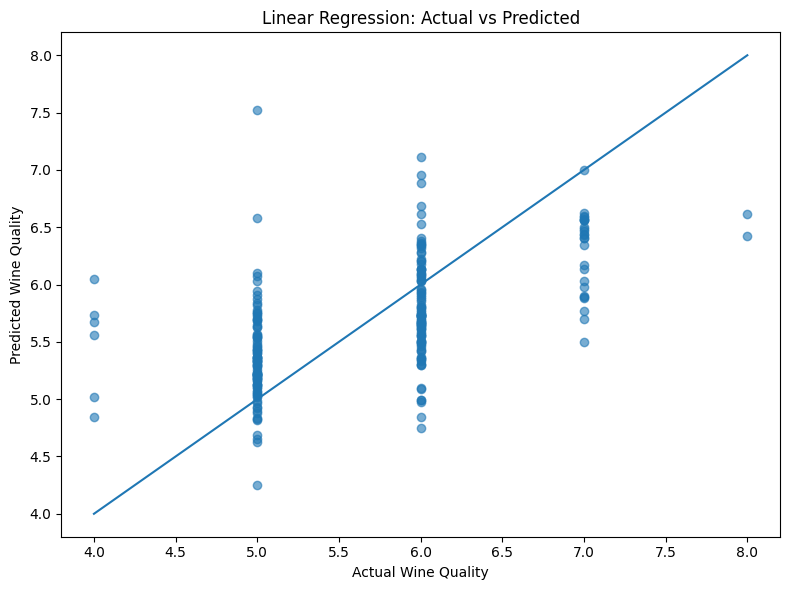

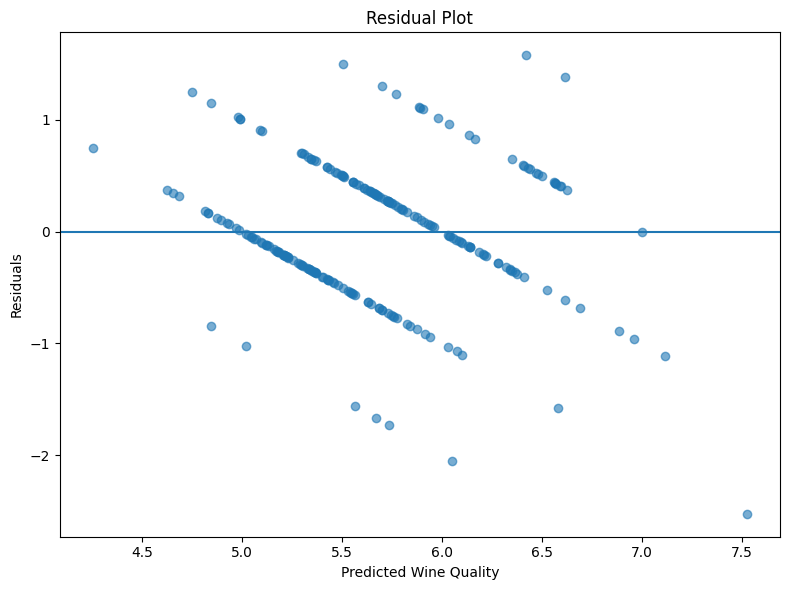


RESULT SAVED
File saved as:
linear_regression_scaling_encoding_results.csv

FINAL CONCLUSION


The WineQT dataset was used to build a complete
Linear Regression Machine Learning Pipeline.

The project included:

1. Dataset Loading
2. Missing Value Handling
3. Feature Identification
4. Numerical Feature Scaling
5. Categorical Feature Encoding
6. Train/Test Data Splitting
7. Linear Regression Model Training
8. Model Evaluation
9. Actual vs Predicted Visualization
10. Residual Analysis

FINAL RESULTS

MAE      : 0.4800
MSE      : 0.3824
RMSE     : 0.6184
R² Score : 0.3128




In [6]:
# ============================================================
# LINEAR REGRESSION, FEATURE SCALING AND ENCODING PROJECT
# Dataset: WineQT.csv
# Target Variable: quality
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 2. CONFIGURATION
# ------------------------------------------------------------

RANDOM_STATE = 42

# Dataset path in Google Drive
DATA_PATH = "/content/drive/MyDrive/Colab/WineQT.csv"

# Target column
TARGET_COL = "quality"


# ------------------------------------------------------------
# 3. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("LINEAR REGRESSION, FEATURE SCALING AND ENCODING PROJECT")
print("=" * 60)

print("\nDataset Loaded Successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


# ------------------------------------------------------------
# 5. CHECK AND REMOVE DUPLICATES
# ------------------------------------------------------------

duplicates = df.duplicated().sum()

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

print("Number of Duplicate Rows:", duplicates)


if duplicates > 0:

    df = df.drop_duplicates()

    print("Duplicate rows removed!")

else:

    print("No duplicate rows found!")


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    columns=[TARGET_COL]
)

y = df[TARGET_COL]


print("\n" + "=" * 60)
print("FEATURES AND TARGET")
print("=" * 60)

print("Feature Shape:", X.shape)

print("Target Shape:", y.shape)


# ------------------------------------------------------------
# 7. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ------------------------------------------------------------

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


print("\nNumerical Features:")
print(numerical_features)


print("\nCategorical Features:")
print(categorical_features)


# ------------------------------------------------------------
# 8. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)


print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ------------------------------------------------------------
# 9. NUMERICAL FEATURE PROCESSING
# ------------------------------------------------------------

numerical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",

            StandardScaler()
        )

    ]

)


# ------------------------------------------------------------
# 10. CATEGORICAL FEATURE PROCESSING
# ------------------------------------------------------------

categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )
        )

    ]

)


# ------------------------------------------------------------
# 11. FEATURE ENCODING + SCALING
# ------------------------------------------------------------

transformers = [

    (

        "numerical",

        numerical_transformer,

        numerical_features

    )

]


# Add categorical processing only if categorical columns exist

if len(categorical_features) > 0:

    transformers.append(

        (

            "categorical",

            categorical_transformer,

            categorical_features

        )

    )


preprocessor = ColumnTransformer(

    transformers=transformers

)


# ------------------------------------------------------------
# 12. CREATE COMPLETE MACHINE LEARNING PIPELINE
# ------------------------------------------------------------

model_pipeline = Pipeline(

    steps=[

        (

            "preprocessor",

            preprocessor

        ),

        (

            "linear_regression",

            LinearRegression()

        )

    ]

)


print("\n" + "=" * 60)
print("PIPELINE CREATED")
print("=" * 60)

print(

    """
Pipeline Steps:

1. Missing Value Handling
2. Feature Scaling
3. Categorical Encoding
4. Linear Regression
"""

)


# ------------------------------------------------------------
# 13. TRAIN THE MODEL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)


model_pipeline.fit(

    X_train,

    y_train

)


print(
    "Linear Regression Model Trained Successfully!"
)


# ------------------------------------------------------------
# 14. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model_pipeline.predict(

    X_test

)


# ------------------------------------------------------------
# 15. MODEL EVALUATION
# ------------------------------------------------------------

mae = mean_absolute_error(

    y_test,

    y_pred

)


mse = mean_squared_error(

    y_test,

    y_pred

)


rmse = np.sqrt(
    mse
)


r2 = r2_score(

    y_test,

    y_pred

)


print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)


print(
    "MAE:",
    round(mae, 4)
)


print(
    "MSE:",
    round(mse, 4)
)


print(
    "RMSE:",
    round(rmse, 4)
)


print(
    "R² Score:",
    round(r2, 4)
)


# ------------------------------------------------------------
# 16. CREATE RESULTS TABLE
# ------------------------------------------------------------

results_df = pd.DataFrame({

    "Metric": [

        "MAE",

        "MSE",

        "RMSE",

        "R2 Score"

    ],

    "Score": [

        mae,

        mse,

        rmse,

        r2

    ]

})


print("\n" + "=" * 60)
print("RESULTS TABLE")
print("=" * 60)

print(
    results_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 17. ACTUAL VS PREDICTED VISUALIZATION
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)


plt.scatter(

    y_test,

    y_pred,

    alpha=0.6

)


# Reference line

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)


plt.plot(

    [min_value, max_value],

    [min_value, max_value]

)


plt.xlabel(
    "Actual Wine Quality"
)


plt.ylabel(
    "Predicted Wine Quality"
)


plt.title(
    "Linear Regression: Actual vs Predicted"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 18. RESIDUAL ANALYSIS
# ------------------------------------------------------------

residuals = y_test - y_pred


plt.figure(
    figsize=(8, 6)
)


plt.scatter(

    y_pred,

    residuals,

    alpha=0.6

)


plt.axhline(

    y=0

)


plt.xlabel(
    "Predicted Wine Quality"
)


plt.ylabel(
    "Residuals"
)


plt.title(
    "Residual Plot"
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 19. SAVE RESULTS
# ------------------------------------------------------------

results_df.to_csv(

    "linear_regression_scaling_encoding_results.csv",

    index=False

)


print("\n" + "=" * 60)
print("RESULT SAVED")
print("=" * 60)

print(
    "File saved as:"
)

print(
    "linear_regression_scaling_encoding_results.csv"
)


# ------------------------------------------------------------
# 20. FINAL CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)


print(f"""

The WineQT dataset was used to build a complete
Linear Regression Machine Learning Pipeline.

The project included:

1. Dataset Loading
2. Missing Value Handling
3. Feature Identification
4. Numerical Feature Scaling
5. Categorical Feature Encoding
6. Train/Test Data Splitting
7. Linear Regression Model Training
8. Model Evaluation
9. Actual vs Predicted Visualization
10. Residual Analysis

FINAL RESULTS

MAE      : {mae:.4f}
MSE      : {mse:.4f}
RMSE     : {rmse:.4f}
R² Score : {r2:.4f}

""")

print("=" * 60)